In [100]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_graphviz
from graphviz import Source
import matplotlib.pyplot as plt

# Decision Trees!
### Regression and PCA

## Regression:

In [101]:
rng = np.random.default_rng(seed=42)
X_quad = rng.random((200, 1)) - 0.5 # a single random input feature
y_quad = (X_quad ** 2) + 0.025 * rng.standard_normal((200, 1))

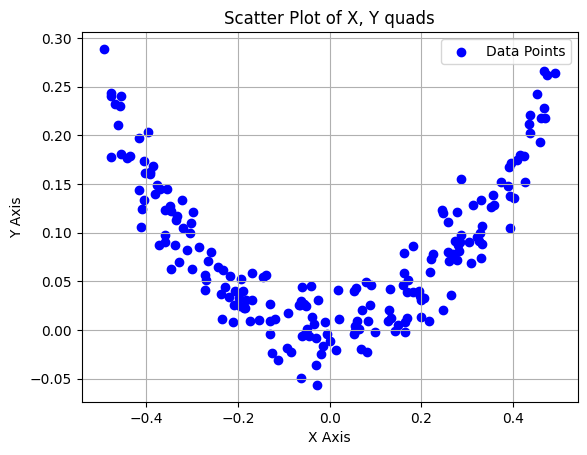

In [102]:
plt.scatter(X_quad, y_quad, color='blue', marker='o', label='Data Points')

plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.title('Scatter Plot of X, Y quads')
plt.grid(True)
plt.legend()

# 4. Display the plot
plt.show()

In [103]:
tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_quad, y_quad)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [104]:
export_graphviz(
    tree_reg,
    out_file="tree_reg.dot",
    feature_names=["X_Quad"],
    rounded=True,
    filled=True
)

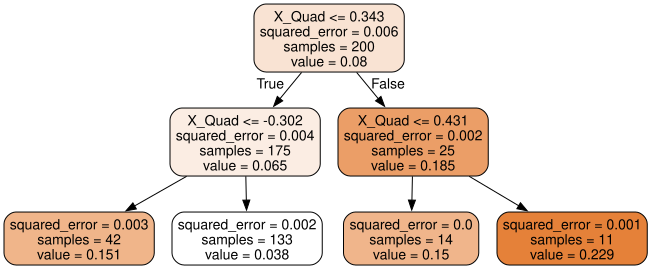

In [105]:
Source.from_file("tree_reg.dot")

Instead of minimizing the impurity, this model minimizes the MSE.
These models are also prone to overfitting, with pruning being important for accurate predictions

### Model Visualization:

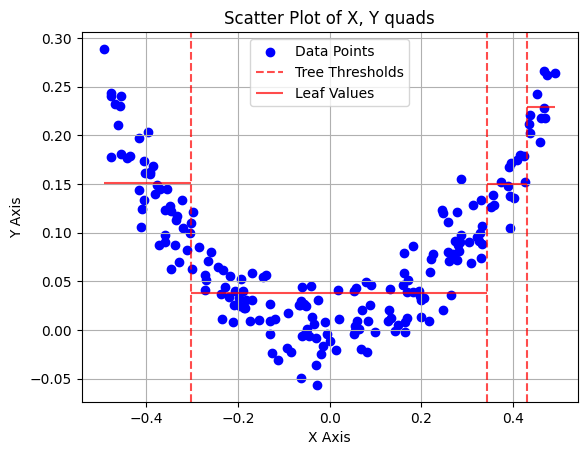

In [106]:
# Extract the thresholds from the trained model
# Internal nodes have children. leaf nodes have a threshold of -2
tree_structure = tree_reg.tree_
all_thresholds = tree_structure.threshold
features = tree_structure.feature

# Filter out leaf nodes (where feature == -2)
# This provides exact X-values where the tree makes its splits
split_thresholds = all_thresholds[features != -2]

# Get the predicted values for ALL nodes in the tree
tree = tree_reg.tree_
all_node_values = tree.value[:, 0, 0]
# Filter using tree.feature to isolate ONLY the leaf values
leaf_values = all_node_values[tree.feature == -2]

# This creates a sorted sequence of all "walls" on the X-axis
sorted_thresholds = np.sort(split_thresholds)
x_min_limit = X_quad.min()
x_max_limit = X_quad.max()
boundaries = np.concatenate(([x_min_limit], sorted_thresholds, [x_max_limit]))

plt.scatter(X_quad, y_quad, color='blue', marker='o', label='Data Points')

# Overlay the decision thresholds as vertical dashed lines
for i, thresh in enumerate(split_thresholds):
    # Only label the first one to keep the legend clean
    label = 'Tree Thresholds' if i == 0 else ""
    plt.axvline(x=thresh, color='red', linestyle='--', alpha=0.7, label=label)

# Overlay the leaf values that are predicted
for i, value in enumerate(leaf_values):
    label = 'Leaf Values' if i == 0 else ""

    # Get the left wall and right wall for this specific leaf region
    current_xmin = boundaries[i]
    current_xmax = boundaries[i + 1]
    
    plt.hlines(y=value, color='red', xmin=current_xmin, xmax=current_xmax, linestyle='solid', alpha=0.7, label=label)


plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.title('Scatter Plot of X, Y quads')
plt.grid(True)
plt.legend()

# 4. Display the plot
plt.show()

Above plot shows thresholds of decision tree (x-values) as well predicted (y-values) for each leaf.

## Principle Component Analysis (PCA):

In [107]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

In [108]:
# load iris
iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

# preprocess
pca_pipeline = make_pipeline(StandardScaler(), PCA())
X_iris_rotated = pca_pipeline.fit_transform(X_iris)

# fit
tree_clf_pca = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf_pca.fit(X_iris_rotated, y_iris)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [109]:
export_graphviz(
    tree_clf_pca,
    out_file="iris_tree_pca.dot",
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

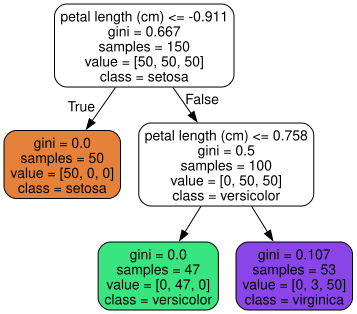

In [110]:
Source.from_file("iris_tree_pca.dot")

Compared to the previous non-PCA preprocessed model with this data set and max-depth 2,
the versicolor gini is now 0, and the virginica gini has an improved, lower score.
Let's visualize these new threshold.

[-0.9111246   0.75787246]


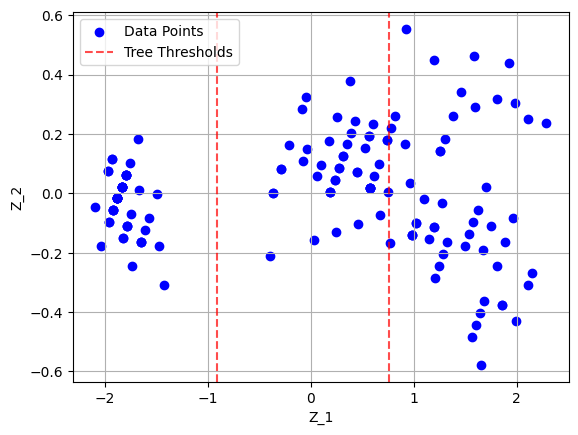

In [124]:
# Extract the thresholds from the trained model
# Internal nodes have children. leaf nodes have a threshold of -2
tree_structure = tree_clf_pca.tree_
all_thresholds = tree_structure.threshold
features = tree_structure.feature

# # Filter out leaf nodes (where feature == -2)
# # This provides exact X-values where the tree makes its splits
split_thresholds = all_thresholds[features != -2]
print(split_thresholds)

x_data = X_iris_rotated[:, 0]
y_data = X_iris_rotated[:, 1]

plt.scatter(x_data, y_data, color='blue', marker='o', label='Data Points')

# # Overlay the decision thresholds as vertical dashed lines
for i, thresh in enumerate(split_thresholds):
    # Only label the first one to keep the legend clean
    label = 'Tree Thresholds' if i == 0 else ""
    plt.axvline(x=thresh, color='red', linestyle='--', alpha=0.7, label=label)

plt.xlabel('Z_1')
plt.ylabel('Z_2')
plt.grid(True)
plt.legend()

# 4. Display the plot
plt.show()